# Air Quality Forecasting

## AI-ML Recruitment Task – Second Year

### Objective
The objective of this project is to analyse historical air-quality measurements
and build a machine-learning model to predict a future air-quality measurement.

### Project Sections
1. Data Understanding and Preprocessing
2. Exploratory Data Analysis
3. Feature Engineering
4. Prediction
5. Model Analysis
6. Insights and Conclusion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/AirQualityUCI.csv', sep=';')


In [ ]:
df.head()


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [ ]:
df .shape

(9471, 17)

In [ ]:
df .columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')

In [ ]:
df . info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(10), object(7)
memory usage: 1.2+ MB


In [ ]:
df . isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114


In [ ]:
df.describe()

,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,1048.990061,-159.090093,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,NaN,NaN
std,329.832710,139.789093,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,921.000000,-200.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,NaN,NaN
50%,1053.000000,-200.000000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,NaN,NaN
75%,1221.000000,-200.000000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,NaN,NaN
max,2040.000000,1189.000000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,NaN,NaN


In [ ]:
df.duplicated().sum()

np.int64(113)

In [ ]:
df.columns.tolist()

['Date',
 'Time',
 'CO(GT)',
 'PT08.S1(CO)',
 'NMHC(GT)',
 'C6H6(GT)',
 'PT08.S2(NMHC)',
 'NOx(GT)',
 'PT08.S3(NOx)',
 'NO2(GT)',
 'PT08.S4(NO2)',
 'PT08.S5(O3)',
 'T',
 'RH',
 'AH',
 'Unnamed: 15',
 'Unnamed: 16']

In [ ]:
df['CO(GT)'].head(20)

,CO(GT)
0,"2,6"
1,2
2,"2,2"
3,"2,2"
4,"1,6"
5,"1,2"
6,"1,2"
7,1
8,"0,9"
9,"0,6"


In [ ]:
clean_df = df.copy()

In [ ]:
(clean_df == -200).sum()

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),366
NMHC(GT),8443
C6H6(GT),0
PT08.S2(NMHC),366
NOx(GT),1639
PT08.S3(NOx),366
NO2(GT),1642


In [ ]:
clean_df.columns.tolist()

['Date',
 'Time',
 'CO(GT)',
 'PT08.S1(CO)',
 'NMHC(GT)',
 'C6H6(GT)',
 'PT08.S2(NMHC)',
 'NOx(GT)',
 'PT08.S3(NOx)',
 'NO2(GT)',
 'PT08.S4(NO2)',
 'PT08.S5(O3)',
 'T',
 'RH',
 'AH',
 'Unnamed: 15',
 'Unnamed: 16']

In [ ]:
clean_df.replace(-200, np.nan, inplace=True)

In [ ]:
clean_df.isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),480
NMHC(GT),8557
C6H6(GT),114
PT08.S2(NMHC),480
NOx(GT),1753
PT08.S3(NOx),480
NO2(GT),1756


In [ ]:
clean_df['DateTime'] = pd.to_datetime(
    clean_df['Date'].astype(str) + ' ' + clean_df['Time'].astype(str),
    dayfirst=True,
    errors='coerce'
)

/tmp/ipykernel_2677/3965313444.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_df['DateTime'] = pd.to_datetime(


In [ ]:
clean_df[['Date', 'Time', 'DateTime']].head()

,Date,Time,DateTime
0,10/03/2004,18.00.00,NaT
1,10/03/2004,19.00.00,NaT
2,10/03/2004,20.00.00,NaT
3,10/03/2004,21.00.00,NaT
4,10/03/2004,22.00.00,NaT


In [ ]:
clean_df['DateTime'].isnull().sum()

np.int64(9471)

In [ ]:
clean_df['DateTime'].isnull().sum()

np.int64(9471)

In [ ]:
clean_df['DateTime'].min(), clean_df['DateTime'].max()

(NaT, NaT)

In [ ]:
missing_summary = pd.DataFrame({
    'Missing Count': clean_df.isnull().sum(),
    'Missing Percentage': clean_df.isnull().mean() * 100
})

missing_summary.sort_values('Missing Percentage', ascending=False)

,Missing Count,Missing Percentage
Unnamed: 15,9471,100.000000
DateTime,9471,100.000000
Unnamed: 16,9471,100.000000
NMHC(GT),8557,90.349488
NO2(GT),1756,18.540809
NOx(GT),1753,18.509133
PT08.S5(O3),480,5.068103
PT08.S4(NO2),480,5.068103
PT08.S2(NMHC),480,5.068103
PT08.S1(CO),480,5.068103


In [ ]:
clean_df = clean_df.sort_values('DateTime').reset_index(drop=True)

In [ ]:
clean_df['DateTime'].duplicated().sum()

np.int64(9470)

In [ ]:
numeric_cols = clean_df.select_dtypes(include=np.number).columns

In [ ]:
clean_df[numeric_cols] = (
    clean_df[numeric_cols]
    .interpolate(method='linear', limit_direction='both')
)

In [ ]:
clean_df.isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),114
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [ ]:
clean_df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16,DateTime
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN,NaT
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN,NaT
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN,NaT
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN,NaT
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN,NaT


In [ ]:
clean_df.shape

(9471, 18)

In [ ]:
clean_df.to_csv('/content/cleaned_air_quality.csv', index=False)

In [ ]:
clean_df.describe().T

,count,mean,min,25%,50%,75%,max,std
PT08.S1(CO),9471.0,1102.673846,647.0,939.0,1071.0,1236.0,2040.0,216.907224
NMHC(GT),9471.0,269.896526,7.0,275.0,275.0,275.0,1189.0,73.805872
PT08.S2(NMHC),9471.0,943.404762,383.0,739.0,914.0,1117.0,2214.0,266.494895
NOx(GT),9471.0,242.199979,2.0,96.057823,181.727273,323.0,1479.0,203.097172
PT08.S3(NOx),9471.0,830.607222,322.0,654.0,800.0,965.0,2683.0,254.912582
NO2(GT),9471.0,110.334653,2.0,76.0,105.0,138.0,340.0,46.618419
PT08.S4(NO2),9471.0,1449.395312,551.0,1215.0,1455.0,1664.0,2775.0,342.962507
PT08.S5(O3),9471.0,1029.93781,221.0,737.0,964.0,1288.5,2523.0,402.6989
Unnamed: 15,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 16,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
(clean_df[numeric_cols] < 0).sum()

,0
PT08.S1(CO),0
NMHC(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0
PT08.S4(NO2),0
PT08.S5(O3),0
Unnamed: 15,0
Unnamed: 16,0


In [ ]:
(clean_df[numeric_cols] < 0).sum()

,0
PT08.S1(CO),0
NMHC(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0
PT08.S4(NO2),0
PT08.S5(O3),0
Unnamed: 15,0
Unnamed: 16,0


In [ ]:
numeric_cols = clean_df.select_dtypes(include=np.number).columns

In [ ]:
clean_df[numeric_cols] = (
    clean_df[numeric_cols]
    .interpolate(method='linear', limit_direction='both')
)

In [ ]:
print("Start:", clean_df['DateTime'].min())
print("End:", clean_df['DateTime'].max())

Start: NaT
End: NaT


In [ ]:
time_diff = clean_df['DateTime'].diff()

time_diff.value_counts().head(10)

,count
DateTime,


In [ ]:
time_diff[time_diff > pd.Timedelta(hours=1)].head(20)

,DateTime


In [ ]:
print("Final rows:", clean_df.shape[0])
print("Final columns:", clean_df.shape[1])

Final rows: 9471
Final columns: 18


In [ ]:
clean_df.to_csv('/content/cleaned_air_quality.csv', index=False)

In [ ]:
clean_df.columns.tolist()

['Date',
 'Time',
 'CO(GT)',
 'PT08.S1(CO)',
 'NMHC(GT)',
 'C6H6(GT)',
 'PT08.S2(NMHC)',
 'NOx(GT)',
 'PT08.S3(NOx)',
 'NO2(GT)',
 'PT08.S4(NO2)',
 'PT08.S5(O3)',
 'T',
 'RH',
 'AH',
 'Unnamed: 15',
 'Unnamed: 16',
 'DateTime']

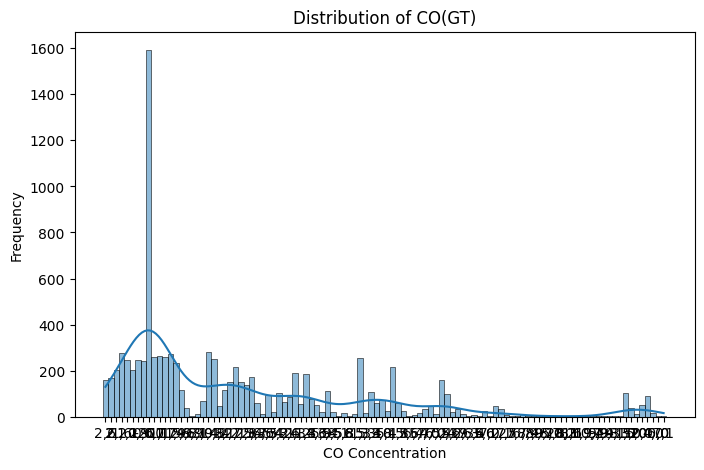

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(clean_df['CO(GT)'], bins=30, kde=True)

plt.title('Distribution of CO(GT)')
plt.xlabel('CO Concentration')
plt.ylabel('Frequency')

plt.show()

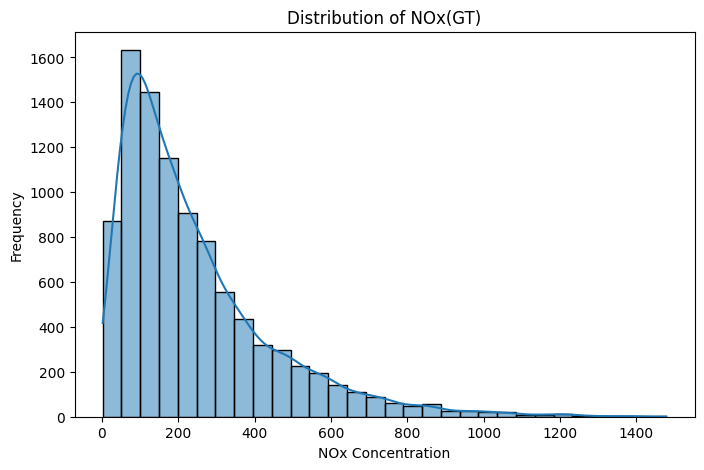

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(clean_df['NOx(GT)'], bins=30, kde=True)

plt.title('Distribution of NOx(GT)')
plt.xlabel('NOx Concentration')
plt.ylabel('Frequency')

plt.show()

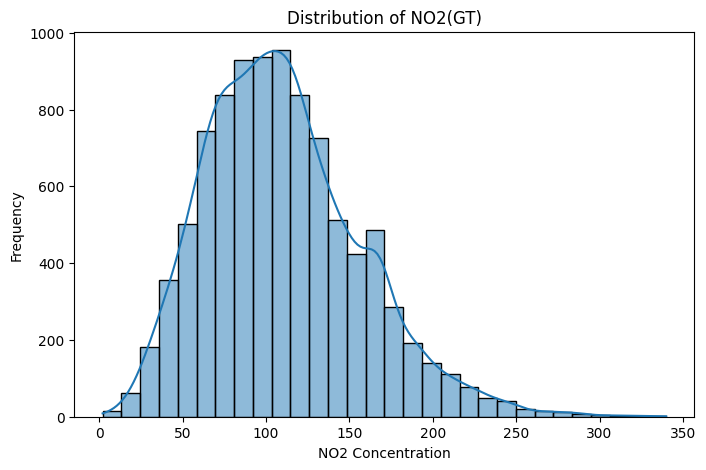

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(clean_df['NO2(GT)'], bins=30, kde=True)

plt.title('Distribution of NO2(GT)')
plt.xlabel('NO2 Concentration')
plt.ylabel('Frequency')

plt.show()

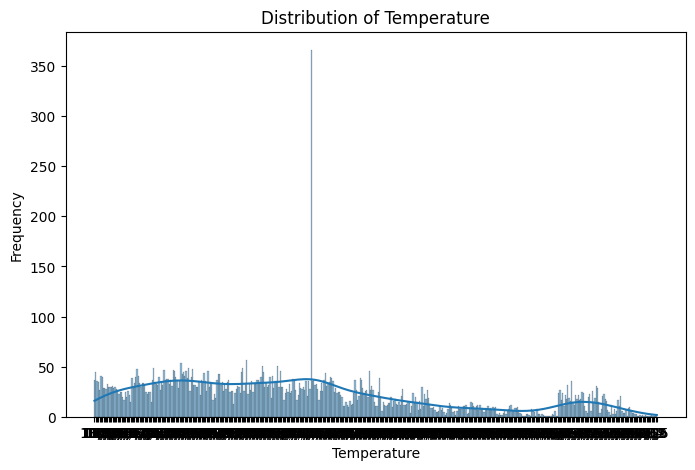

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(clean_df['T'], bins=30, kde=True)

plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')

plt.show()

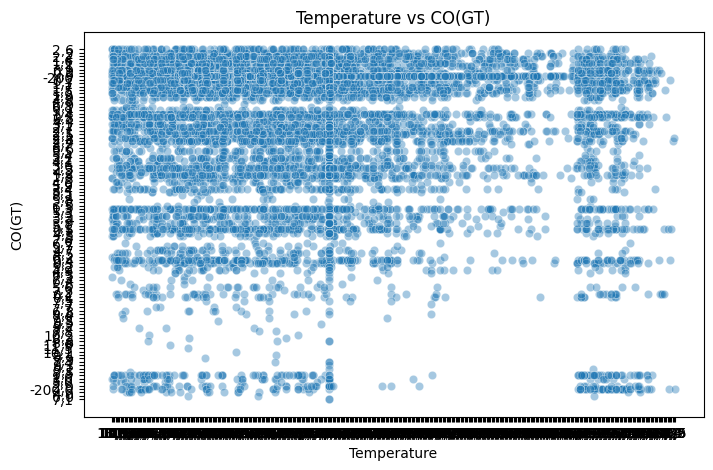

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x='T',
    y='CO(GT)',
    alpha=0.4
)

plt.title('Temperature vs CO(GT)')
plt.xlabel('Temperature')
plt.ylabel('CO(GT)')

plt.show()

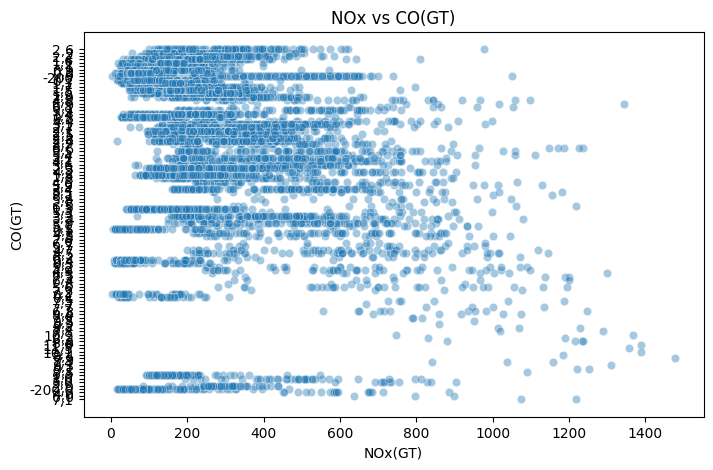

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x='NOx(GT)',
    y='CO(GT)',
    alpha=0.4
)

plt.title('NOx vs CO(GT)')
plt.xlabel('NOx(GT)')
plt.ylabel('CO(GT)')

plt.show()

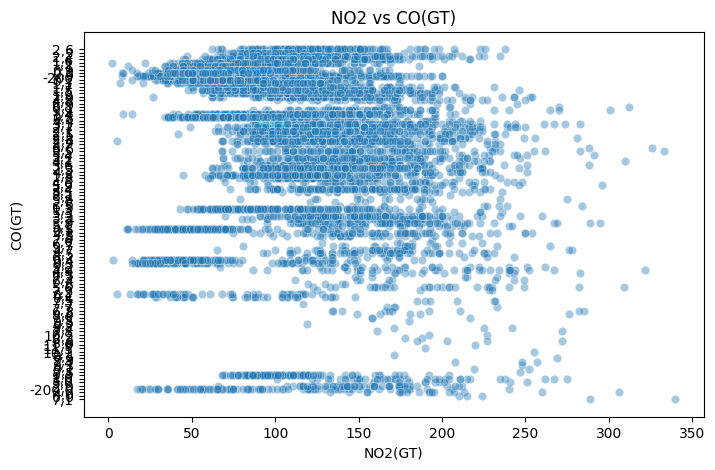

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x='NO2(GT)',
    y='CO(GT)',
    alpha=0.4
)

plt.title('NO2 vs CO(GT)')
plt.xlabel('NO2(GT)')
plt.ylabel('CO(GT)')

plt.show()

In [ ]:
correlation = clean_df.select_dtypes(include=np.number).corr()

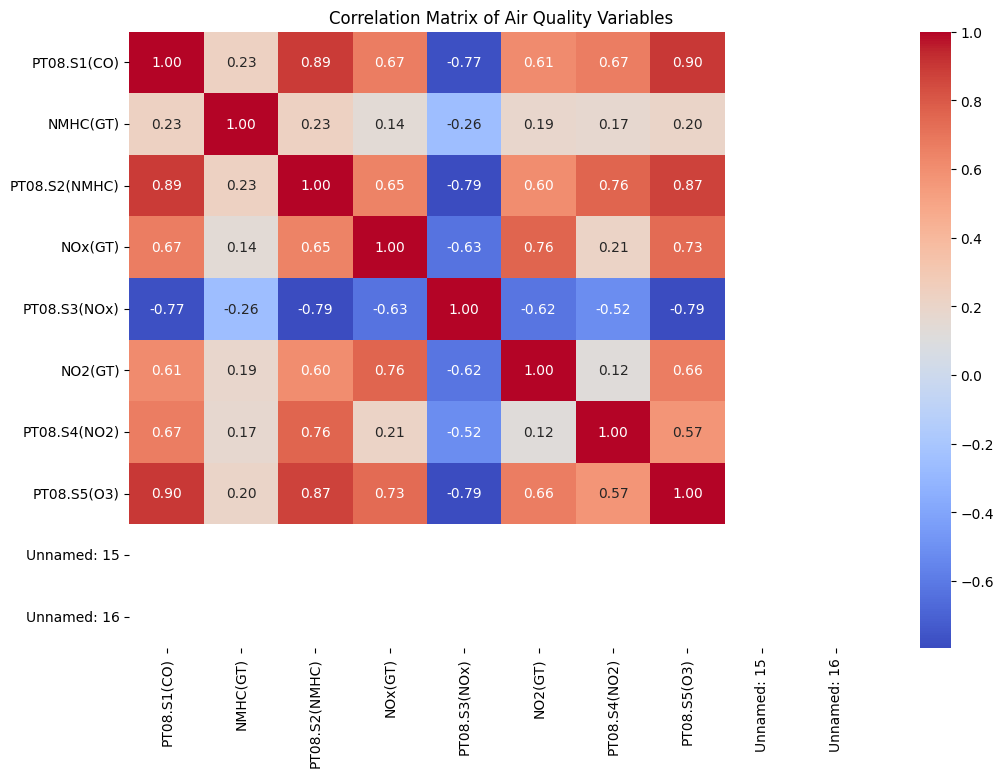

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Air Quality Variables')

plt.show()

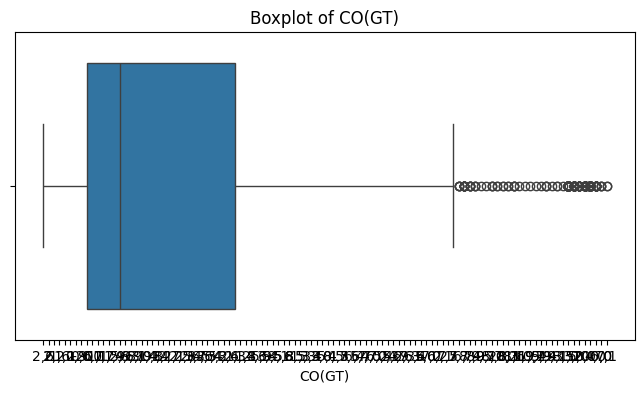

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=clean_df['CO(GT)'])

plt.title('Boxplot of CO(GT)')

plt.show()

In [ ]:
clean_df['Hour'] = clean_df['DateTime'].dt.hour
clean_df['DayOfWeek'] = clean_df['DateTime'].dt.dayofweek
clean_df['Month'] = clean_df['DateTime'].dt.month

In [ ]:
clean_df['CO_Lag_1'] = clean_df['CO(GT)'].shift(1)

In [ ]:
clean_df['CO_Lag_2'] = clean_df['CO(GT)'].shift(2)

In [ ]:
clean_df['Target_CO'] = clean_df['CO(GT)'].shift(-1)

In [ ]:
clean_df = clean_df.dropna().reset_index(drop=True)

In [ ]:
features = [
    'CO(GT)',
    'CO_Lag_1',
    'CO_Lag_2',
    'CO_Rolling_Mean_3',
    'NOx(GT)',
    'NO2(GT)',
    'T',
    'RH',
    'AH',
    'Hour',
    'DayOfWeek',
    'Month'
]

target = 'Target_CO'

X = clean_df [features]
y = clean_df[target]

print(X.shape)
print(y.shape)

KeyError: "['CO_Rolling_Mean_3'] not in index"

In [ ]:
clean_df['CO_Rolling_Mean_3'] = (
    clean_df['CO(GT)']
    .shift(1)
    .rolling(window=3)
    .mean()
)

In [ ]:
clean_df['Target_CO'] = clean_df['CO(GT)'].shift(-1)

In [ ]:
clean_df = clean_df.dropna().reset_index(drop=True)

print(clean_df.shape)

(0, 25)


In [ ]:
features = [
    'CO(GT)',
    'CO_Lag_1',
    'CO_Lag_2',
    'CO_Rolling_Mean_3',
    'NOx(GT)',
    'NO2(GT)',
    'T',
    'RH',
    'AH',
    'Hour',
    'DayOfWeek',
    'Month'
]

target = 'Target_CO'

X = clean_df[features]
y = clean_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (0, 12)
y shape: (0,)


In [ ]:
split_index = int(len(clean_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 0
Testing samples: 0


In [ ]:
model_df = df.copy()

# Remove unwanted empty columns, if present
model_df = model_df.loc[
    :,
    ~model_df.columns.astype(str).str.startswith('Unnamed')
]

# Convert measurement columns to numbers
for col in model_df.columns[2:]:
    model_df[col] = (
        model_df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# -200 means missing in this dataset
model_df.replace(-200, np.nan, inplace=True)

# Create DateTime
model_df['DateTime'] = pd.to_datetime(
    model_df['Date'].astype(str) + ' ' + model_df['Time'].astype(str),
    dayfirst=True,
    errors='coerce'
)

# Sort chronologically
model_df = model_df.sort_values('DateTime').reset_index(drop=True)

print("Rows:", len(model_df))
print("Columns:", len(model_df.columns))

/tmp/ipykernel_2677/20484971.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  model_df['DateTime'] = pd.to_datetime(


Rows: 9471
Columns: 16


In [ ]:
model_df['Target_CO'] = model_df['CO(GT)'].shift(-1)

model_df['Hour'] = model_df['DateTime'].dt.hour
model_df['DayOfWeek'] = model_df['DateTime'].dt.dayofweek
model_df['Month'] = model_df['DateTime'].dt.month

In [ ]:
predictor_cols = [
    'CO(GT)',
    'NOx(GT)',
    'NO2(GT)',
    'T',
    'RH',
    'AH'
]

model_df[predictor_cols] = model_df[predictor_cols].ffill()

In [ ]:
model_df['CO_Lag_1'] = model_df['CO(GT)'].shift(1)

model_df['CO_Lag_2'] = model_df['CO(GT)'].shift(2)

model_df['CO_Rolling_Mean_3'] = (
    model_df['CO(GT)']
    .shift(1)
    .rolling(window=3)
    .mean()
)

In [ ]:
features = [
    'CO(GT)',
    'CO_Lag_1',
    'CO_Lag_2',
    'CO_Rolling_Mean_3',
    'NOx(GT)',
    'NO2(GT)',
    'T',
    'RH',
    'AH',
    'Hour',
    'DayOfWeek',
    'Month'
]

target = 'Target_CO'

In [ ]:
model_df = model_df.dropna(
    subset=features + [target]
).reset_index(drop=True)

X = model_df[features]
y = model_df[target]

print("Final rows:", len(model_df))
print("X shape:", X.shape)
print("y shape:", y.shape)

Final rows: 0
X shape: (0, 12)
y shape: (0,)


In [ ]:
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 0
Testing samples: 0


In [ ]:
print("model_df shape:", model_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

model_df shape: (0, 23)
X shape: (0, 12)
y shape: (0,)


In [ ]:
print(model_df[features + [target]].isnull().sum())

CO(GT)               0
CO_Lag_1             0
CO_Lag_2             0
CO_Rolling_Mean_3    0
NOx(GT)              0
NO2(GT)              0
T                    0
RH                   0
AH                   0
Hour                 0
DayOfWeek            0
Month                0
Target_CO            0
dtype: int64


In [ ]:
print(model_df[features + [target]].isnull().sum())

CO(GT)               0
CO_Lag_1             0
CO_Lag_2             0
CO_Rolling_Mean_3    0
NOx(GT)              0
NO2(GT)              0
T                    0
RH                   0
AH                   0
Hour                 0
DayOfWeek            0
Month                0
Target_CO            0
dtype: int64


In [ ]:
print("Total rows:", len(X))
print("Split index:", int(len(X) * 0.8))

Total rows: 0
Split index: 0


In [ ]:
# Use a simpler set of features

features = [
    'CO(GT)',
    'CO_Lag_1',
    'CO_Lag_2',
    'CO_Rolling_Mean_3',
    'T',
    'RH',
    'AH',
    'Hour',
    'DayOfWeek',
    'Month'
]

target = 'Target_CO'

# Keep only required columns
model_df = model_df.dropna(
    subset=features + [target]
).reset_index(drop=True)

X = model_df[features]
y = model_df[target]

print("Final dataset shape:", model_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

Final dataset shape: (0, 23)
X shape: (0, 10)
y shape: (0,)


In [ ]:
print("Number of samples:", len(X))

Number of samples: 0


In [ ]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 0
Testing samples: 0


In [ ]:
# Start again from the original dataset

model_df = df.copy()

# Remove unwanted empty column
model_df = model_df.loc[
    :, ~model_df.columns.astype(str).str.startswith('Unnamed')
]

# Convert measurements
for col in model_df.columns[2:]:
    model_df[col] = (
        model_df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Convert -200 to missing
model_df.replace(-200, np.nan, inplace=True)

# Create DateTime
model_df['DateTime'] = pd.to_datetime(
    model_df['Date'].astype(str) + ' ' + model_df['Time'].astype(str),
    dayfirst=True,
    errors='coerce'
)

# Sort by time
model_df = model_df.sort_values('DateTime').reset_index(drop=True)

print("Original model rows:", len(model_df))
print(model_df.shape)

/tmp/ipykernel_2677/623106222.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  model_df['DateTime'] = pd.to_datetime(


Original model rows: 9471
(9471, 16)


In [ ]:
# Use CO as the forecasting target

model_df['Target_CO'] = model_df['CO(GT)'].shift(-1)

# Time features
model_df['Hour'] = model_df['DateTime'].dt.hour
model_df['DayOfWeek'] = model_df['DateTime'].dt.dayofweek
model_df['Month'] = model_df['DateTime'].dt.month

# Fill CO using previous available value only
model_df['CO(GT)'] = model_df['CO(GT)'].ffill()

# Create lag features
model_df['CO_Lag_1'] = model_df['CO(GT)'].shift(1)
model_df['CO_Lag_2'] = model_df['CO(GT)'].shift(2)

# Previous 3 observations average
model_df['CO_Rolling_Mean_3'] = (
    model_df['CO(GT)']
    .shift(1)
    .rolling(3)
    .mean()
)

print(model_df[['CO(GT)', 'CO_Lag_1',
                'CO_Lag_2', 'CO_Rolling_Mean_3',
                'Target_CO']].head(10))

   CO(GT)  CO_Lag_1  CO_Lag_2  CO_Rolling_Mean_3  Target_CO
0     2.6       NaN       NaN                NaN        2.0
1     2.0       2.6       NaN                NaN        2.2
2     2.2       2.0       2.6                NaN        2.2
3     2.2       2.2       2.0           2.266667        1.6
4     1.6       2.2       2.2           2.133333        1.2
5     1.2       1.6       2.2           2.000000        1.2
6     1.2       1.2       1.6           1.666667        1.0
7     1.0       1.2       1.2           1.333333        0.9
8     0.9       1.0       1.2           1.133333        0.6
9     0.6       0.9       1.0           1.033333        NaN


In [5]:
features = [
    'CO(GT)',
    'CO_Lag_1',
    'CO_Lag_2',
    'CO_Rolling_Mean_3',
    'Hour',
    'DayOfWeek',
    'Month'
]

target = 'Target_CO'

In [9]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 